In [23]:
import sys
sys.path.append("../")
import importlib

import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.utils import from_networkx

import GNNInterpreter
from GNNInterpreter.gnninterpreter import *


In [24]:
config = {
    "DATASET_NAME": "MUTAG", 
    "MAX_NODES": 20, 
    "device": "cpu"
}

# Data

In [25]:
import new_src.dataAdapter
from new_src.dataAdapter import load_dataset
importlib.reload(new_src.dataAdapter)

data = load_dataset(config.get("DATASET_NAME"))
cls_split = data.split_by_class()

In [26]:
from new_src.utils import convert_hard_to_soft_edges

print(data[0])
convert_hard_to_soft_edges(data[0])

Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])


Data(edge_index=[2, 289], x=[17, 7], edge_attr=[289, 4], y=[1], edge_weight=[289])

# Explainee

In [21]:
import new_src.explainee
from new_src.explainee import fit_explainee
importlib.reload(new_src.explainee)

explainee, _ = fit_explainee(
    dataset_name = config.get("DATASET_NAME"),
    root="data",
    hidden=64,
    layers=3,
    dropout=0.2,
    epochs=10,
    batch_size=32,
    lr=1e-3,
    device=config.get("device")
)


# Extract embeddings. 
mean_embeds = [
    torch.cat([explainee(batch.to(config.get("device")))["embeds"]
               for batch in DataLoader(subset, batch_size=64)])
         .mean(dim=0)
    for subset in cls_split
]
mean_embeds = [m.detach() for m in mean_embeds]

[001/10] train_loss=0.7039  val_acc=0.789
[002/10] train_loss=0.5972  val_acc=0.789
[003/10] train_loss=0.5833  val_acc=0.789
[004/10] train_loss=0.5606  val_acc=0.789
[005/10] train_loss=0.5695  val_acc=0.789
[006/10] train_loss=0.5566  val_acc=0.789
[007/10] train_loss=0.5486  val_acc=0.789
[008/10] train_loss=0.5451  val_acc=0.789
[009/10] train_loss=0.5394  val_acc=0.789
[010/10] train_loss=0.5324  val_acc=0.737
Test Accuracy: 0.632


# GED Approximator

Generating synthetic GED dataset with 1 perturbations per graph...
Created GED dataset with 188 pairs.


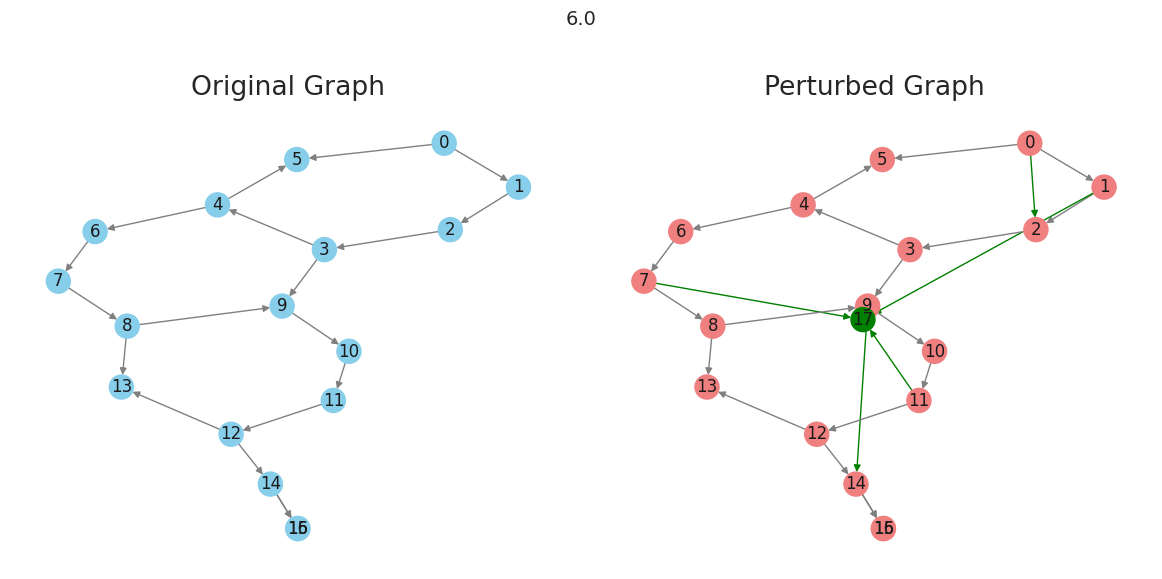

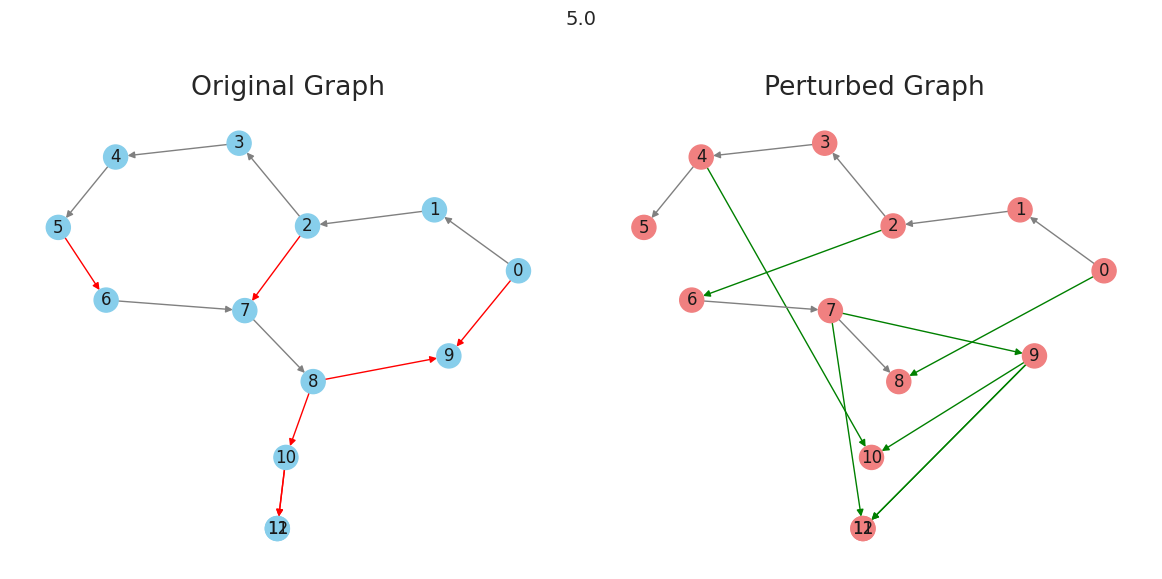

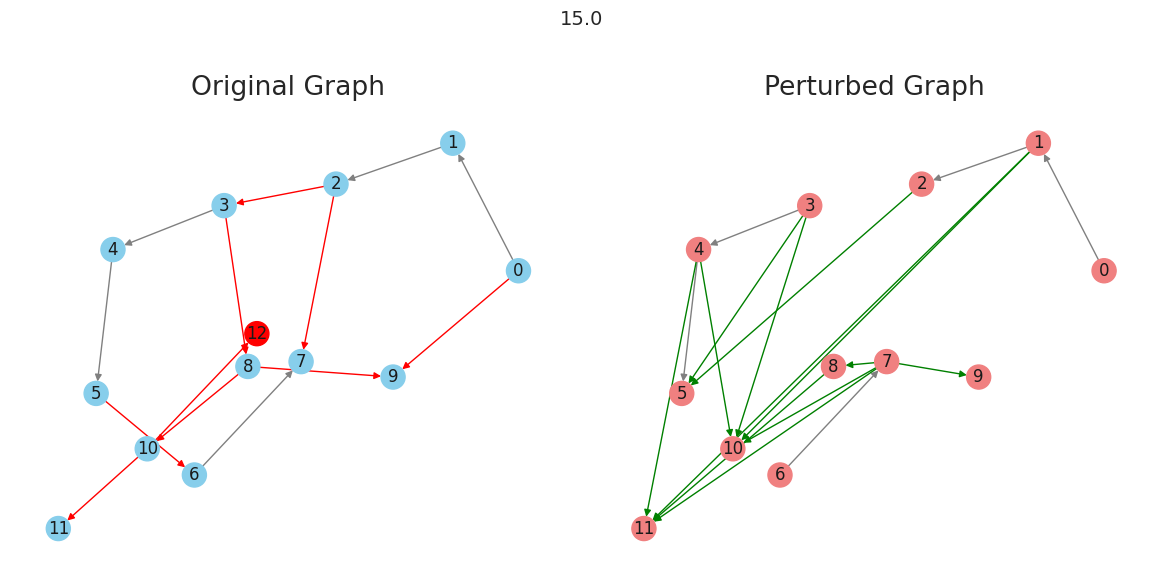

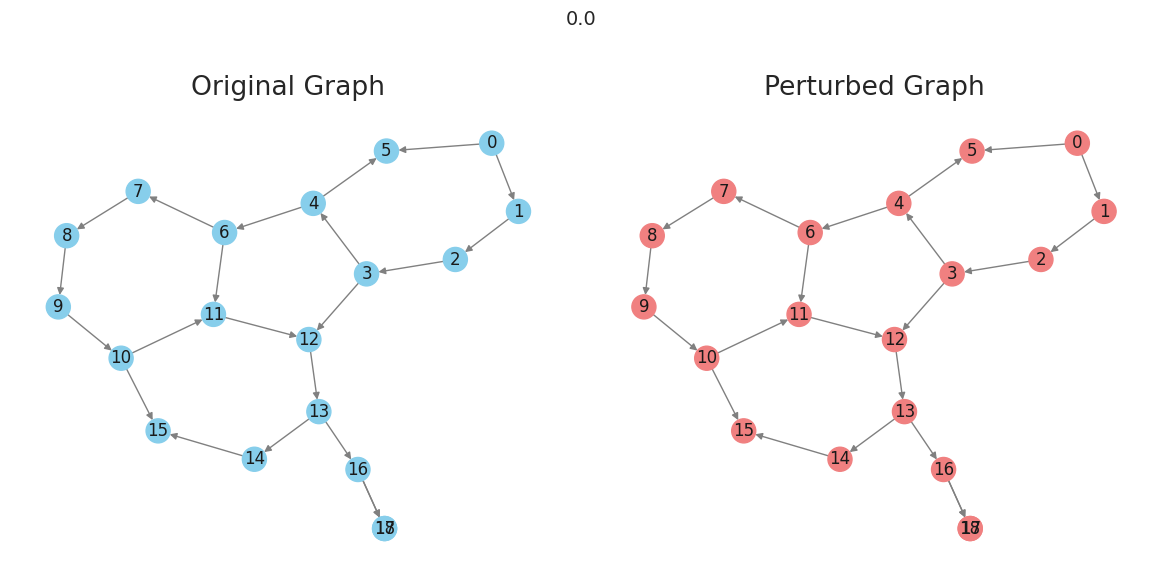

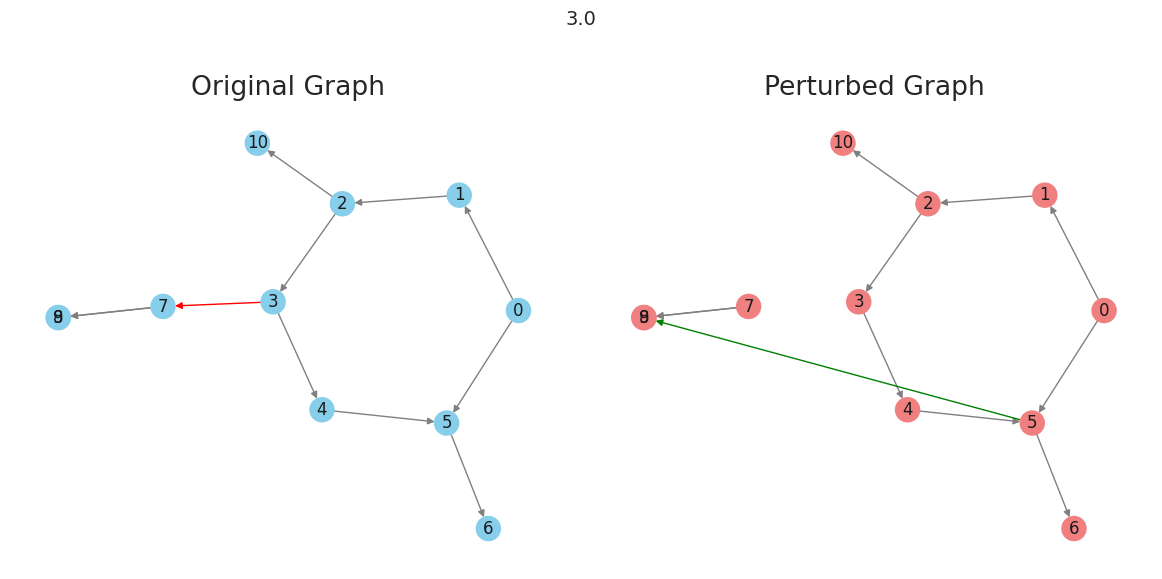

In [22]:
import new_src.ged_dataset
importlib.reload(new_src.ged_dataset)

from new_src.ged_dataset import create_and_save_ged_dataset, plot_graph_pair

ged_dataset = create_and_save_ged_dataset(
    data, 
    out_path=None, 
    n_perturbations=1,
    node_add_prob=0.5,
    node_remove_prob=0.5,
    edge_add_prob=0.1, 
    edge_remove_prob=0.1
)

print(f"Created GED dataset with {len(ged_dataset)} pairs.")

for i in range(5):
    g1, g2, ged_norm = ged_dataset[i]
    raw_ged = getattr(g1, "raw_ged", ged_norm)
    plot_graph_pair(g1, g2, label=raw_ged)

# Generator

In [5]:
import new_src.graph_level_dist
importlib.reload(new_src.graph_level_dist)

from new_src.graph_level_dist import dummyDist

In [6]:
def train_generator(cls_idx, data):
    trainer = Trainer(
        sampler=(
            s := GraphSampler(
                    max_nodes=config.get("MAX_NODES"),
                    num_node_cls=len(data.NODE_CLS),
                    num_edge_cls=len(data.EDGE_CLS), 
                    temperature=0.15,
                    learn_node_feat=len(data.NODE_CLS) > 0, 
                    learn_edge_feat=len(data.EDGE_CLS) > 0, 
            )
        ),
        discriminator=explainee,
        criterion=WeightedCriterion([
            dict(key="logits", criterion=ClassScoreCriterion(class_idx=cls_idx, mode='maximize'), weight=1),
            dict(key="embeds", criterion=EmbeddingCriterion(target_embedding=mean_embeds[cls_idx]), weight=50),
            dict(key="cont_data", criterion=dummyDist(), weight=1), 
        ]),
        optimizer=(o := torch.optim.SGD(s.parameters(), lr=1)),
        scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
        dataset=data,
        budget_penalty=BudgetPenalty(budget=10, order=2, beta=1),
    )

    trainer.train(
        iterations=200,
        target_probs={cls_idx: (0.9, 1.0)},
        target_size=30,
        w_budget_init=0.5,
        w_budget_inc=1.1,
        w_budget_dec=0.95,
        k_samples=32
    )

    example = trainer.evaluate(threshold=0.5)

    example = from_networkx(example)

    if "label" in example: 
        example.x = F.one_hot(
            example.label, num_classes=len(data.NODE_CLS)
        ).float()

    if "edge_label" in example: 
        example.edge_attr = F.one_hot(
            example.edge_label, num_classes=len(data.EDGE_CLS)
        ).float()

    example.y = torch.tensor(cls_idx).float()
    
    return example

In [7]:
import new_src.utils
from new_src.utils import plot_graph
importlib.reload(new_src.utils)



sample = train_generator(0, data), 
plot_graph(sample[0], data)

  0%|          | 0/200 [00:00<?, ?it/s]

DataBatch(x=[640, 3], edge_index=[2, 12160], edge_weight=[12160], batch=[640], ptr=[33])
DataBatch(x=[640, 3], edge_index=[2, 12160], edge_weight=[12160], batch=[640], ptr=[33])
DataBatch(x=[640, 3], edge_index=[2, 12160], edge_weight=[12160], batch=[640], ptr=[33])
DataBatch(x=[640, 3], edge_index=[2, 12160], edge_weight=[12160], batch=[640], ptr=[33])
DataBatch(x=[640, 3], edge_index=[2, 12160], edge_weight=[12160], batch=[640], ptr=[33])
DataBatch(x=[640, 3], edge_index=[2, 12160], edge_weight=[12160], batch=[640], ptr=[33])
DataBatch(x=[640, 3], edge_index=[2, 12160], edge_weight=[12160], batch=[640], ptr=[33])
DataBatch(x=[640, 3], edge_index=[2, 12160], edge_weight=[12160], batch=[640], ptr=[33])
DataBatch(x=[640, 3], edge_index=[2, 12160], edge_weight=[12160], batch=[640], ptr=[33])
DataBatch(x=[640, 3], edge_index=[2, 12160], edge_weight=[12160], batch=[640], ptr=[33])
DataBatch(x=[640, 3], edge_index=[2, 12160], edge_weight=[12160], batch=[640], ptr=[33])
DataBatch(x=[640, 3],

KeyboardInterrupt: 

# Evaluation